In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [82]:
df = pd.read_csv("fifa_world_cup_500_rows_with_nans.csv")

In [83]:
df.head()

,match_id,date,home_team,away_team,home_goals,away_goals,winner
0,1,2018-11-07,France,Italy,1.0,5.0,Italy
1,2,2026-10-14,England,Mexico,4.0,NaN,NaN
2,3,2016-04-07,Spain,Argentina,4.0,4.0,Draw
3,4,2020-02-04,Netherlands,Belgium,2.0,3.0,NaN
4,5,2014-04-13,NaN,Argentina,2.0,3.0,Argentina


In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   match_id    500 non-null    int64  
 1   date        500 non-null    str    
 2   home_team   460 non-null    str    
 3   away_team   460 non-null    str    
 4   home_goals  460 non-null    float64
 5   away_goals  460 non-null    float64
 6   winner      460 non-null    str    
dtypes: float64(2), int64(1), str(4)
memory usage: 27.5 KB


In [85]:
df.isnull().sum()

match_id       0
date           0
home_team     40
away_team     40
home_goals    40
away_goals    40
winner        40
dtype: int64

In [86]:
# Fill categorical columns with the most frequent value (mode)
df["home_team"] = df["home_team"].fillna(df["home_team"].mode()[0])
df["away_team"] = df["away_team"].fillna(df["away_team"].mode()[0])
df["winner"] = df["winner"].fillna(df["winner"].mode()[0])



In [87]:
# Fill numerical columns with the median
df["home_goals"] = df["home_goals"].fillna(df["home_goals"].median())
df["away_goals"] = df["away_goals"].fillna(df["away_goals"].median())

In [88]:
df.isnull().sum()

match_id      0
date          0
home_team     0
away_team     0
home_goals    0
away_goals    0
winner        0
dtype: int64

In [89]:
df["home_goals"]

0      1.0
1      4.0
2      4.0
3      2.0
4      2.0
      ... 
495    5.0
496    3.0
497    5.0
498    2.0
499    0.0
Name: home_goals, Length: 500, dtype: float64

In [90]:
df["away_goals"]

0      5.0
1      3.0
2      4.0
3      3.0
4      3.0
      ... 
495    0.0
496    3.0
497    5.0
498    3.0
499    4.0
Name: away_goals, Length: 500, dtype: float64

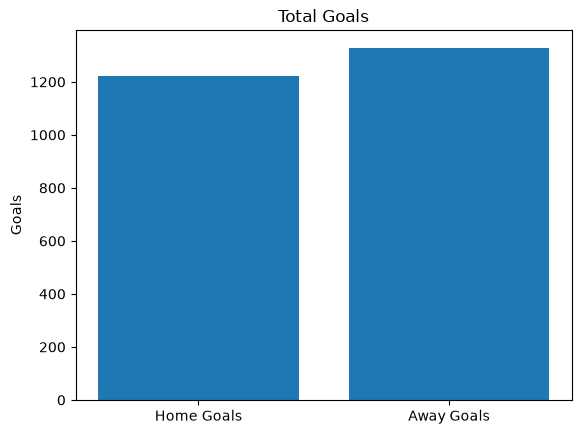

In [91]:
import matplotlib.pyplot as plt

goals = [
    df["home_goals"].sum(),
    df["away_goals"].sum()
]

labels = ["Home Goals", "Away Goals"]

plt.bar(labels, goals)

plt.title("Total Goals")
plt.ylabel("Goals")

plt.show()

In [92]:
#df.columns

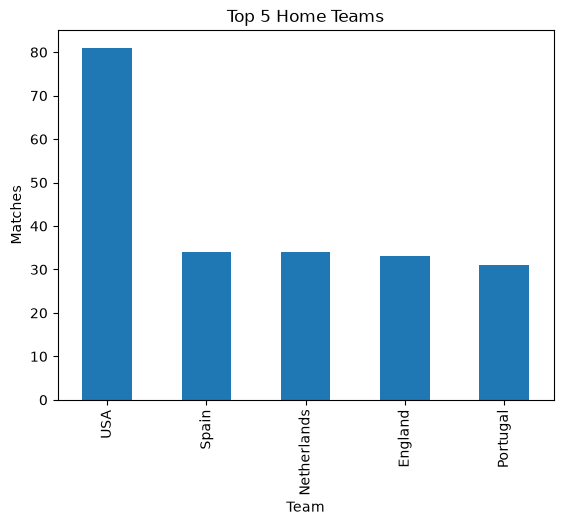

In [93]:
import matplotlib.pyplot as plt

df["home_team"].value_counts().head(5).plot(kind="bar")

plt.title("Top 5 Home Teams")
plt.xlabel("Team")
plt.ylabel("Matches")

plt.show()

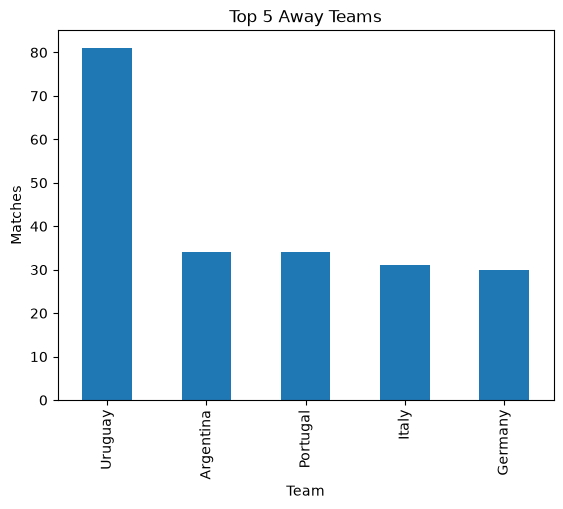

In [94]:
import matplotlib.pyplot as plt

df["away_team"].value_counts().head(5).plot(kind="bar")

plt.title("Top 5 Away Teams")
plt.xlabel("Team")
plt.ylabel("Matches")

plt.show()

In [95]:
#df.duplicated().sum()

In [96]:
df["date"] = pd.to_datetime(df["date"])

In [97]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

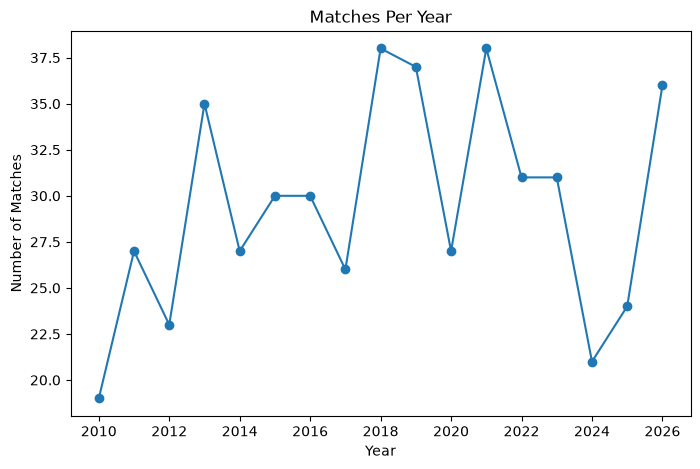

In [98]:
plt.figure(figsize=(8,5))

df["year"].value_counts().sort_index().plot(
    kind="line",
    marker="o"
)

plt.title("Matches Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Matches")

plt.show()

In [99]:
df.drop("date", axis=1, inplace=True)

In [100]:
df.drop("match_id", axis=1, inplace=True)

In [101]:
df = pd.get_dummies(
    df,
    columns=["home_team", "away_team"],
    drop_first=True
)

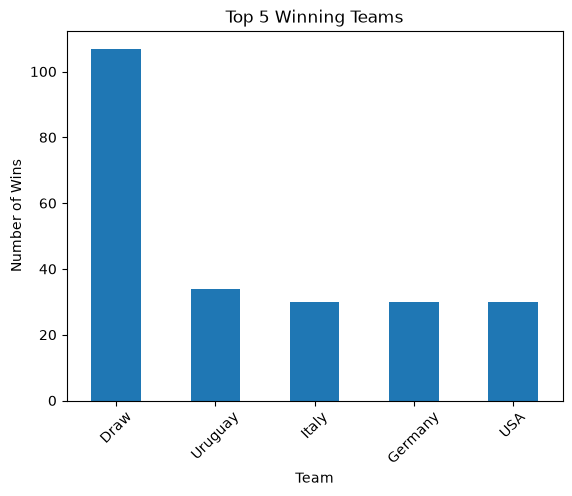

In [102]:
import matplotlib.pyplot as plt

df["winner"].value_counts().head(5).plot(kind="bar")

plt.title("Top 5 Winning Teams")
plt.xlabel("Team")
plt.ylabel("Number of Wins")

plt.xticks(rotation=45)
plt.show()

In [103]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["winner"] = le.fit_transform(df["winner"])

In [104]:
X = df.drop("winner", axis=1)
y = df["winner"]

In [105]:
from sklearn.model_selection import train_test_split

In [106]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [107]:
from sklearn.preprocessing import StandardScaler

In [108]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [109]:
#from sklearn.linear_model import LogisticRegression

In [110]:
from sklearn.tree import DecisionTreeClassifier
DTC=DecisionTreeClassifier()

In [111]:
DTC.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [112]:
df=DTC.predict(X_train)

In [113]:
model=DTC.score(X_train,y_train)

In [114]:
import joblib

joblib.dump(model, "logistic_regression_model.pkl")

['logistic_regression_model.pkl']

In [115]:
model = joblib.load("logistic_regression_model.pkl")